[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch13.ipynb)

Notebook Bab 13 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Demo memakai dua data kecil: Meuse untuk autokorelasi spasial dan Zachary Karate Club untuk struktur graf. Keduanya berjalan dengan pandas, scikit-learn, matplotlib, dan NetworkX saja.


## Persiapan


In [1]:
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '4')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


def fit_node_score(train_df, test_df, cols):
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE),
    )
    pipe.fit(train_df[cols], train_df['is_officer'])
    pred = pipe.predict(test_df[cols])
    return accuracy_score(test_df['is_officer'], pred)


## Section 1 - Demo: Spasial dan Graf


## Spasial: Meuse dan validasi berbasis blok


In [2]:
MEUSE_DIR = section_data_dir('ch13_meuse')
KARATE_DIR = section_data_dir('ch13_karate')

meuse_stats = json.loads((MEUSE_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
karate_stats = json.loads((KARATE_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
meuse = pd.read_parquet(MEUSE_DIR / 'meuse.parquet')
meuse_cv = pd.read_csv(MEUSE_DIR / 'meuse_spatial_cv_scores.csv')

print(f"Meuse rows: {meuse_stats['rows']} | zinc range: {meuse_stats['zinc_min']:.0f}..{meuse_stats['zinc_max']:.0f} ppm")
print(f"Moran's I log-zinc (8-NN): {meuse_stats['log_zinc_morans_i_k8']:.3f}")
print(f"Near 8-NN median |diff|: {meuse_stats['near_8nn_median_abs_log_zinc_diff']:.3f}")
print(f"Far top-quartile median |diff|: {meuse_stats['far_top_quartile_median_abs_log_zinc_diff']:.3f}")
print(f"Coordinate kNN RMSE random CV: {meuse_stats['coordinate_knn_random_cv_rmse']:.3f}")
print(f"Coordinate kNN RMSE spatial block CV: {meuse_stats['coordinate_knn_spatial_block_cv_rmse']:.3f}")


Meuse rows: 155 | zinc range: 113..1839 ppm
Moran's I log-zinc (8-NN): 0.443
Near 8-NN median |diff|: 0.421
Far top-quartile median |diff|: 0.685
Coordinate kNN RMSE random CV: 0.490
Coordinate kNN RMSE spatial block CV: 0.662


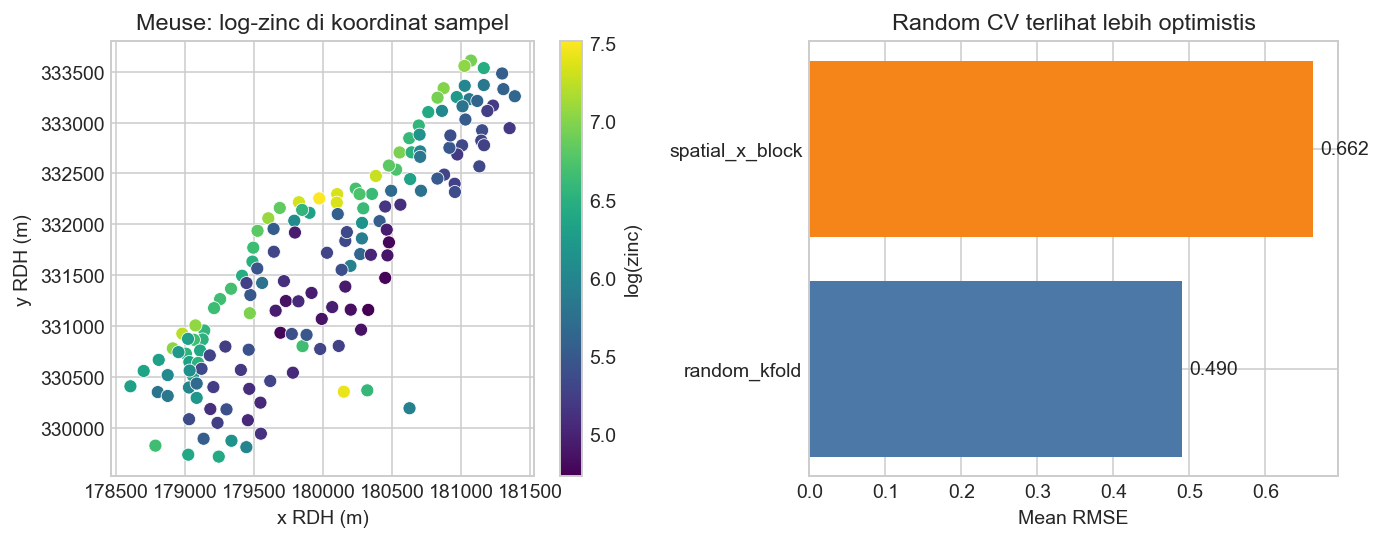

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sc = axes[0].scatter(meuse['x'], meuse['y'], c=meuse['log_zinc'], cmap='viridis', s=45, edgecolor='white', linewidth=0.4)
axes[0].set_title('Meuse: log-zinc di koordinat sampel')
axes[0].set_xlabel('x RDH (m)')
axes[0].set_ylabel('y RDH (m)')
plt.colorbar(sc, ax=axes[0], label='log(zinc)')
summary = meuse_cv.groupby('scheme')['rmse'].mean().reset_index()
axes[1].barh(summary['scheme'], summary['rmse'], color=['#4c78a8', '#f58518'])
axes[1].set_xlabel('Mean RMSE')
axes[1].set_title('Random CV terlihat lebih optimistis')
for i, value in enumerate(summary['rmse']):
    axes[1].text(value + 0.01, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


## Graf: Karate Club, centrality, dan embedding spektral


In [4]:
nodes = pd.read_parquet(KARATE_DIR / 'karate_node_features.parquet')
edges = pd.read_csv(KARATE_DIR / 'karate_edges.csv')
karate_scores = pd.read_csv(KARATE_DIR / 'karate_node_classification_scores.csv')

print(f"Karate graph: {karate_stats['nodes']} nodes, {karate_stats['edges']} edges")
print(f"Degree range: {karate_stats['degree_min']}..{karate_stats['degree_max']}")
print(f"Greedy communities: {karate_stats['greedy_modularity_communities']} sizes={karate_stats['greedy_modularity_community_sizes']}")
print(f"Fixed split cross edges: {karate_stats['fixed_split_cross_edges']}")
print(karate_scores.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

train_nodes = nodes[nodes['split'] == 'train']
test_nodes = nodes[nodes['split'] == 'test']
centrality_cols = ['degree', 'weighted_degree', 'clustering', 'betweenness', 'closeness', 'pagerank', 'core_number']
spectral_cols = [c for c in nodes.columns if c.startswith('spectral_')]
print('Centrality recomputed accuracy:', f"{fit_node_score(train_nodes, test_nodes, centrality_cols):.3f}")
print('Spectral recomputed accuracy  :', f"{fit_node_score(train_nodes, test_nodes, spectral_cols):.3f}")


Karate graph: 34 nodes, 78 edges
Degree range: 1..17
Greedy communities: 3 sizes=[18, 11, 5]
Fixed split cross edges: 38
          representation  accuracy
              centrality     0.667
      spectral_embedding     1.000
centrality_plus_spectral     0.833
Centrality recomputed accuracy: 0.667
Spectral recomputed accuracy  : 1.000


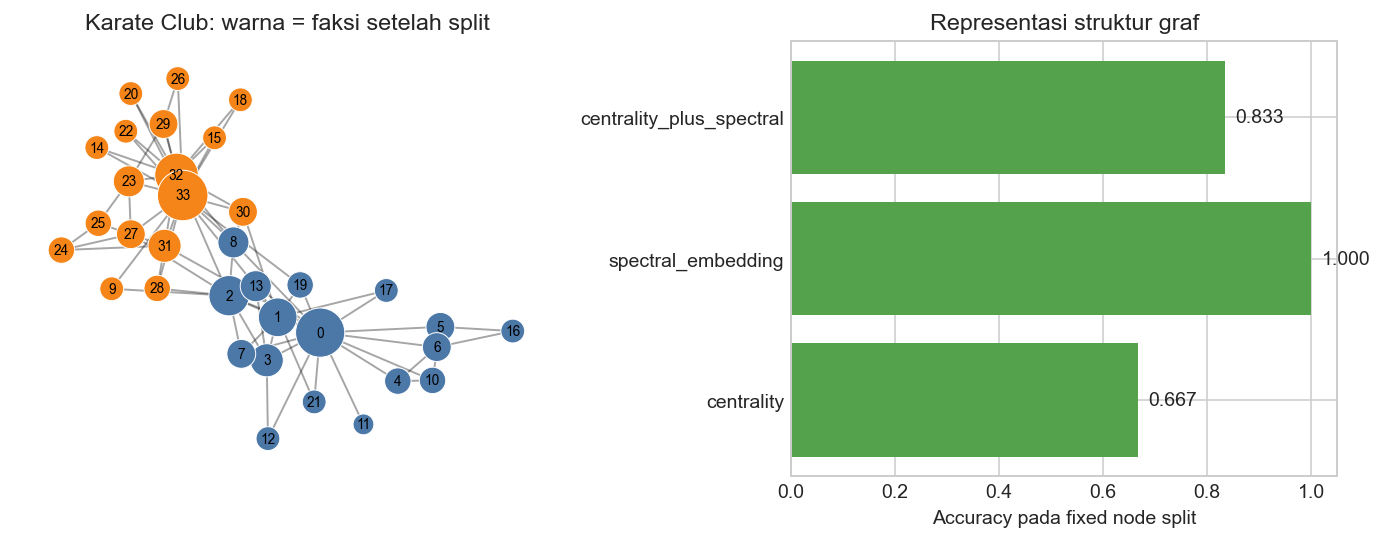

In [5]:
G = nx.Graph()
for row in edges.itertuples(index=False):
    G.add_edge(int(row.source), int(row.target), weight=float(row.weight))
for row in nodes.itertuples(index=False):
    G.nodes[int(row.node)]['club'] = row.club
pos = nx.spring_layout(G, seed=RANDOM_STATE, weight='weight')
color_map = {'Mr. Hi': '#4c78a8', 'Officer': '#f58518'}
node_colors = [color_map[G.nodes[n]['club']] for n in G.nodes]
node_sizes = [80 + 35 * G.degree[n] for n in G.nodes]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
nx.draw_networkx_edges(G, pos, ax=axes[0], alpha=0.35, width=1)
nx.draw_networkx_nodes(G, pos, ax=axes[0], node_color=node_colors, node_size=node_sizes, edgecolors='white', linewidths=0.5)
nx.draw_networkx_labels(G, pos, ax=axes[0], font_size=7)
axes[0].set_title('Karate Club: warna = faksi setelah split')
axes[0].axis('off')
axes[1].barh(karate_scores['representation'], karate_scores['accuracy'], color='#54a24b')
axes[1].set_xlim(0, 1.05)
axes[1].set_xlabel('Accuracy pada fixed node split')
axes[1].set_title('Representasi struktur graf')
for i, value in enumerate(karate_scores['accuracy']):
    axes[1].text(value + 0.02, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


>
> ?? **Amati.** Pada Meuse, titik yang dekat cenderung punya log-zinc lebih mirip, sehingga random CV memberi RMSE yang terlalu nyaman dibanding blok spasial. Pada Karate Club, fitur centrality saja menangkap sebagian sinyal faksi, tetapi embedding spektral dari struktur graf jauh lebih kuat pada split kecil ini. Jumlah cross-edge pada split acak juga mengingatkan bahwa validasi graf harus sadar struktur, bukan sekadar acak per baris.


## Section 2 - Mini Project

## Soal

Gunakan data Karate Club yang sama, lalu uji apakah representasi graf masih kuat ketika informasi struktur dibatasi.

Tugas:

1. Pakai `mini_nodes` dan `mini_edges` dari sel di bawah.
2. Bandingkan regresi logistik dengan fitur centrality saja, embedding spektral saja, dan gabungan keduanya.
3. Hitung berapa edge yang melintasi train/test pada split yang dipakai, lalu jelaskan mengapa angka itu penting untuk validasi graf.

**Luaran:** tabel akurasi, jumlah cross-edge, dan 3-4 kalimat analisis.

**Kriteria penilaian:** (a) fitur dilatih hanya pada node train; (b) target `is_officer` tidak dipakai sebagai fitur; (c) analisis menyebut risiko leakage lewat sisi graf.


In [6]:
# DATA AWAL (jangan diubah)
mini_nodes = nodes.copy()
mini_edges = edges.copy()
print('Nodes:', mini_nodes.shape, '| Edges:', mini_edges.shape)
print('Split:', mini_nodes['split'].value_counts().to_dict())
print('Target:', mini_nodes['club'].value_counts().to_dict())
mini_nodes.head()


Nodes: (34, 16) | Edges: (78, 3)
Split: {'train': 22, 'test': 12}
Target: {'Mr. Hi': 17, 'Officer': 17}


,node,club,is_officer,split,greedy_community,degree,weighted_degree,clustering,betweenness,closeness,pagerank,core_number,spectral_0,spectral_1,spectral_2,spectral_3
0,0,Mr. Hi,0,train,1,16,42,0.066311,0.473769,0.568966,0.088508,4,0.276397,-0.118729,0.051827,-0.053514
1,1,Mr. Hi,0,train,1,9,29,0.166915,0.064015,0.485294,0.057415,4,0.133314,-0.335869,0.009721,-0.021469
2,2,Mr. Hi,0,train,1,10,33,0.131427,0.069413,0.559322,0.062767,4,0.061600,-0.263054,0.007974,0.072744
3,3,Mr. Hi,0,test,1,6,18,0.300001,0.002525,0.464789,0.037212,4,0.129077,-0.313859,0.043861,-0.121990
4,4,Mr. Hi,0,test,2,3,8,0.249594,0.000947,0.379310,0.020504,3,0.237340,0.162083,0.000861,-0.026523


In [7]:
# Kerjakan di sini.
# Petunjuk: gunakan centrality_cols, spectral_cols, train_nodes, test_nodes, dan fit_node_score dari demo.
